# **1. Problem Definition**

## Background
Flood risk in the Netherlands is becoming a significant risk due to heavy hourly precipitation. ML models such as XGBoost are able to predict and detect events like this from data. However, they are difficult to interpret -> post-hoc methods like SHAP and LIME can be used to explain them. It is unclear whether they agree and how stable the explanations are. This project aims to look at that gap.

## Research Goal
Train an XGBoost model on ERA5 data for De Bilt to classify hourly extreme precipitation



# **2. Import libraries**

In [8]:
import xarray as xr
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from ydata_profiling import ProfileReport

# **3. Load the data**

In [12]:
file_path = Path("../data/raw/era5_debilt_2010_2025_basic.nc")
ds = xr.open_dataset(file_path, engine="netcdf4")
print("Dataset loaded correct")
print(ds)
df = ds.to_dataframe().reset_index()


Dataset loaded correct
<xarray.Dataset> Size: 5MB
Dimensions:     (valid_time: 131520)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1MB 2010-01-01 ... 2025-01-01T23:...
    latitude    float64 8B ...
    longitude   float64 8B ...
Data variables:
    u10         (valid_time) float32 526kB ...
    v10         (valid_time) float32 526kB ...
    d2m         (valid_time) float32 526kB ...
    t2m         (valid_time) float32 526kB ...
    msl         (valid_time) float32 526kB ...
    sp          (valid_time) float32 526kB ...
    tcc         (valid_time) float32 526kB ...
    tp          (valid_time) float32 526kB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Rang

# **4. Check**

In [14]:
df.head()

,valid_time,u10,v10,d2m,t2m,msl,sp,tcc,tp,latitude,longitude
0,2010-01-01 00:00:00,-3.206360,-4.415176,270.572205,273.083435,99796.5000,99723.859375,1.000000,0.000034,52.0,5.25
1,2010-01-01 01:00:00,-3.581848,-4.482193,270.281982,273.042145,99785.6250,99713.945312,0.997070,0.000022,52.0,5.25
2,2010-01-01 02:00:00,-3.827850,-4.368881,270.057373,273.026550,99773.6875,99701.164062,0.953491,0.000012,52.0,5.25
3,2010-01-01 03:00:00,-3.738113,-4.246582,269.936249,273.034119,99770.0625,99697.851562,0.975220,0.000010,52.0,5.25
4,2010-01-01 04:00:00,-3.380920,-4.337769,269.910706,273.063354,99808.8125,99736.203125,0.928223,0.000006,52.0,5.25


In [15]:
print(df.shape)

(131520, 11)


In [16]:
display(df.dtypes)

valid_time    datetime64[ns]
u10                  float32
v10                  float32
d2m                  float32
t2m                  float32
msl                  float32
sp                   float32
tcc                  float32
tp                   float32
latitude             float64
longitude            float64
dtype: object

# **5. Light cleaning (if needed)** 

In [18]:
missing_values = df.isnull().sum()
print("\nMissing values per column:")
display(missing_values[missing_values > 0])


Missing values per column:


Series([], dtype: int64)

In [19]:
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")


Number of duplicate rows: 0


In [20]:
if "valid_time" in df.columns:
    duplicate_times = df["valid_time"].duplicated().sum()
    print(f"\nDuplicate timestamps: {duplicate_times}")


Duplicate timestamps: 0


No cleaning needed at first.

# **6. EDA**

### **6.1 Variable Understanding and Units**

| Variable | Meaning | Unit | Interpretation |
|---|---|---|---|
| u10 | 10m east-west wind component | m/s | Positive = eastward wind |
| v10 | 10m north-south wind component | m/s | Positive = northward wind |
| d2m | 2m dewpoint temperature | Kelvin (K) | Atmospheric moisture indicator |
| t2m | 2m air temperature | Kelvin (K) | Near-surface air temperature |
| msl | Mean sea level pressure | Pascal (Pa) | Atmospheric pressure adjusted to sea level |
| sp | Surface pressure | Pascal (Pa) | Pressure at surface level |
| tcc | Total cloud cover | 0â€“1 fraction | 1 = fully cloudy |
| tp | Total precipitation | meters (m) | Total accumulated precipitation |

### **6.2 Profiling Report**

In [ ]:
# Nice feature to immediately see any notable points
profile = ProfileReport(
    df, title="ERA5 climate dataset profiling report", explorative=True
)
profile.to_file("../reports/era5_eda_profile.html")
print("Succes")

### **6.3 Target Variable Analysis**

In [21]:
# Convert totalprecipitation from meters to millimeters
df["tp_mm"] = df["tp"] * 1000

In [22]:
df["tp_mm"].describe()

count    131520.000000
mean          0.101043
std           0.322111
min           0.000000
25%           0.000000
50%           0.000477
75%           0.039577
max          12.814045
Name: tp_mm, dtype: float64

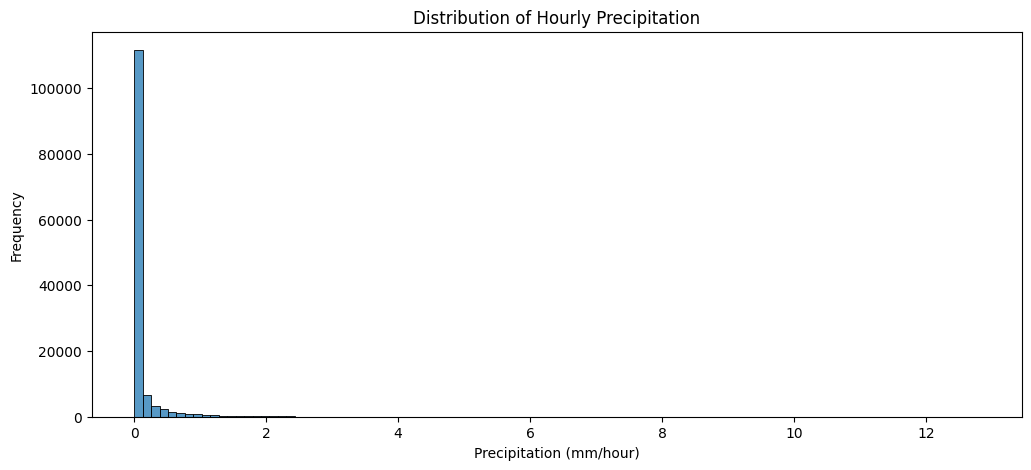

In [29]:
# Distribution of precipitation per hour
plt.figure(figsize=(12, 5))
sns.histplot(df["tp_mm"], bins=100)
plt.title("Distribution of Hourly Precipitation")
plt.xlabel("Precipitation (mm/hour)")
plt.ylabel("Frequency")
plt.show()

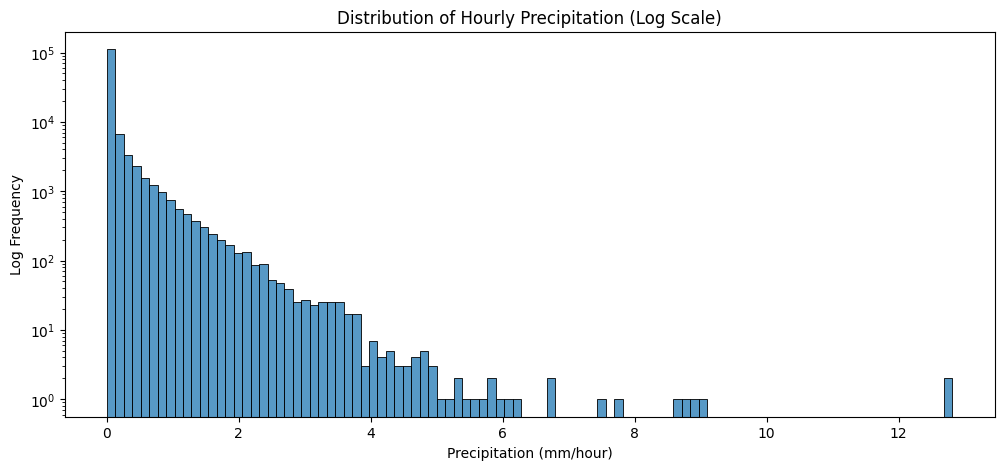

In [30]:
# Distribution using log scale, is for nonlinear plotting method. Count in orders of magnitude
plt.figure(figsize=(12, 5))
sns.histplot(df["tp_mm"], bins=100)
plt.yscale("log")
plt.title("Distribution of Hourly Precipitation (Log Scale)")
plt.xlabel("Precipitation (mm/hour)")
plt.ylabel("Log Frequency")
plt.show()

In [31]:
df["tp_mm"].sort_values(ascending=False).head(20)

48212     12.814045
108543    12.720108
108544     9.044647
82603      8.931160
38905      8.767128
127292     8.690834
48211      7.766724
82604      7.481575
119312     6.767750
127291     6.675720
82633      6.175995
14166      6.066799
82632      5.922318
118980     5.876541
100512     5.831242
72985      5.677223
75422      5.608559
103464     5.507469
75516      5.258560
13429      5.258560
Name: tp_mm, dtype: float32

In climate science people often use percentile based thresholds to define extreme precipitation events. It allows us and the model to transform this into classification problem. 

In [32]:
threshold_95 = df["tp_mm"].quantile(0.95)
approx_extreme = (df["tp_mm"] >= threshold_95).astype(int)
approx_extreme.value_counts(normalize=True) * 100

tp_mm
0    94.998479
1     5.001521
Name: proportion, dtype: float64

### **6.4 Missing Values Analysis**

In [34]:
print(df.isnull().sum())
print(f"Total missing values: {df.isnull().sum().sum()}")

valid_time    0
u10           0
v10           0
d2m           0
t2m           0
msl           0
sp            0
tcc           0
tp            0
latitude      0
longitude     0
tp_mm         0
dtype: int64
Total missing values: 0


Once again a confirmation -> 0 missing values

### **6.5 Univariate Analysis**

In [35]:
# Select numerical variables
numerical_columns = ["u10", "v10", "d2m", "t2m", "msl", "sp", "tcc", "tp_mm"]

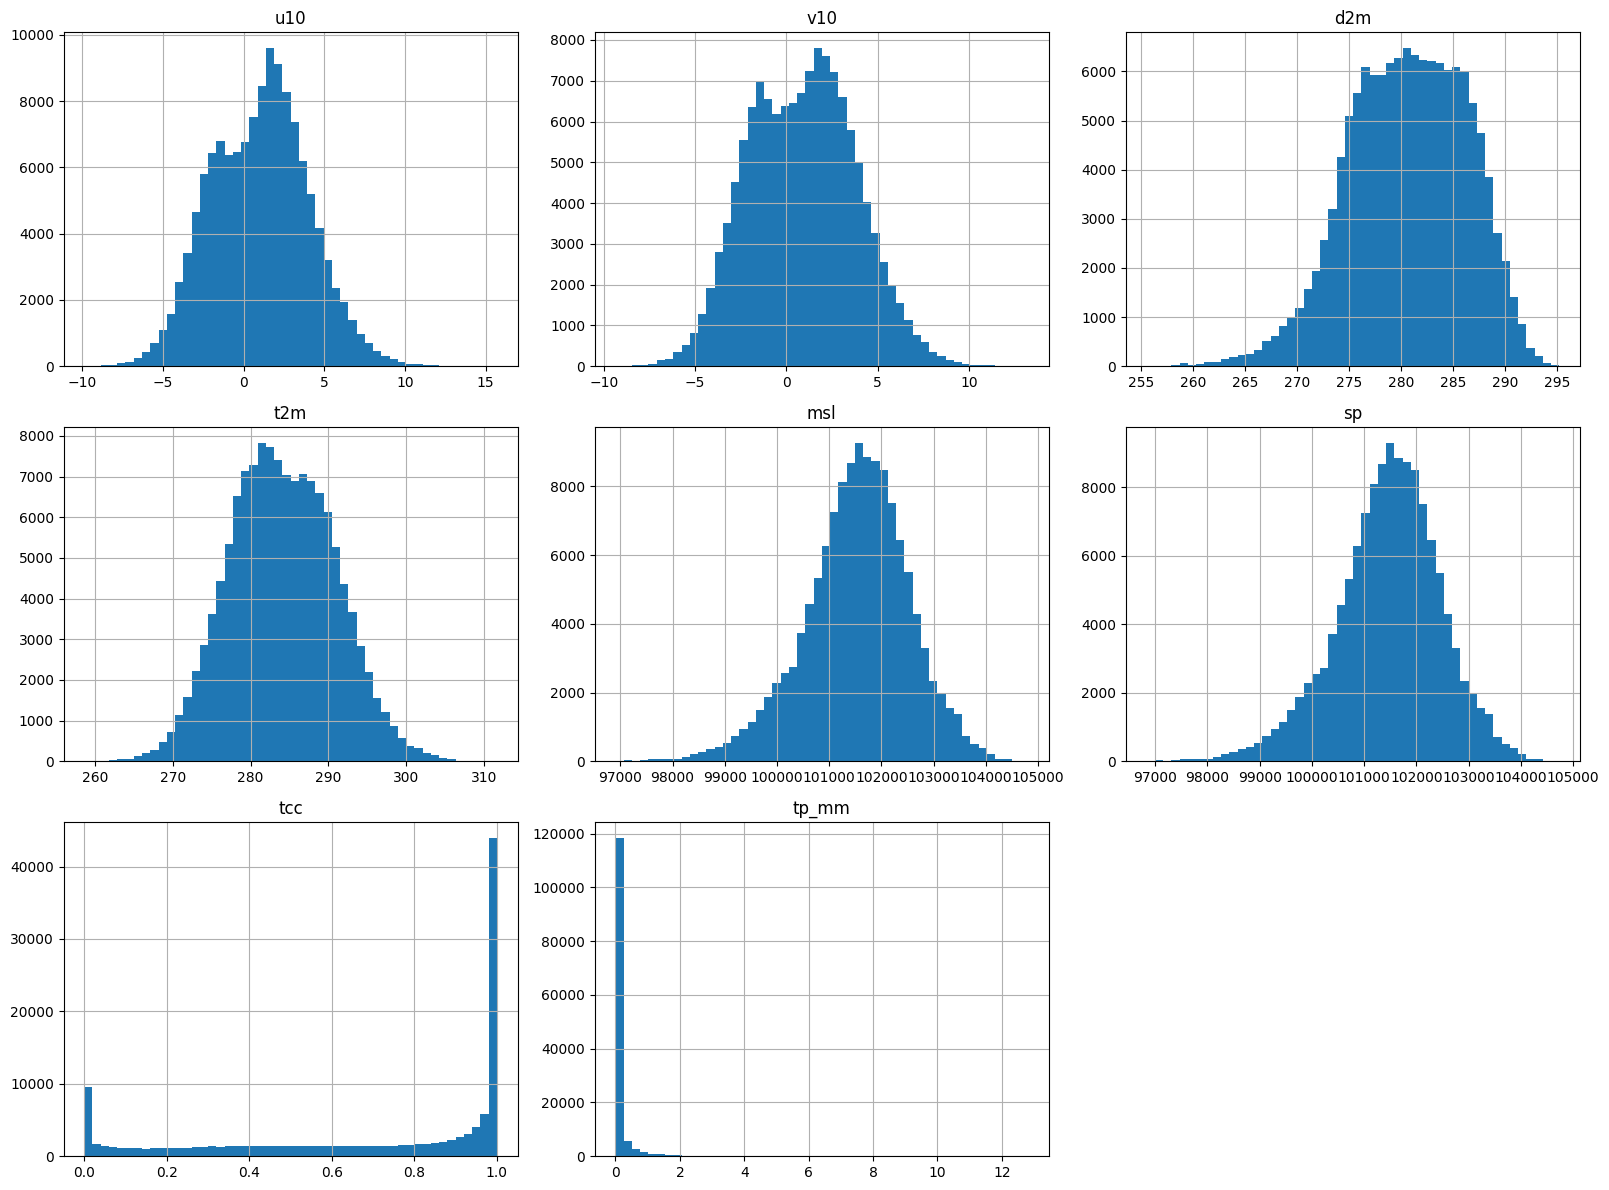

In [36]:
# Histograms for all numerical variables
df[numerical_columns].hist(figsize=(16, 12), bins=50)
plt.tight_layout()
plt.show()

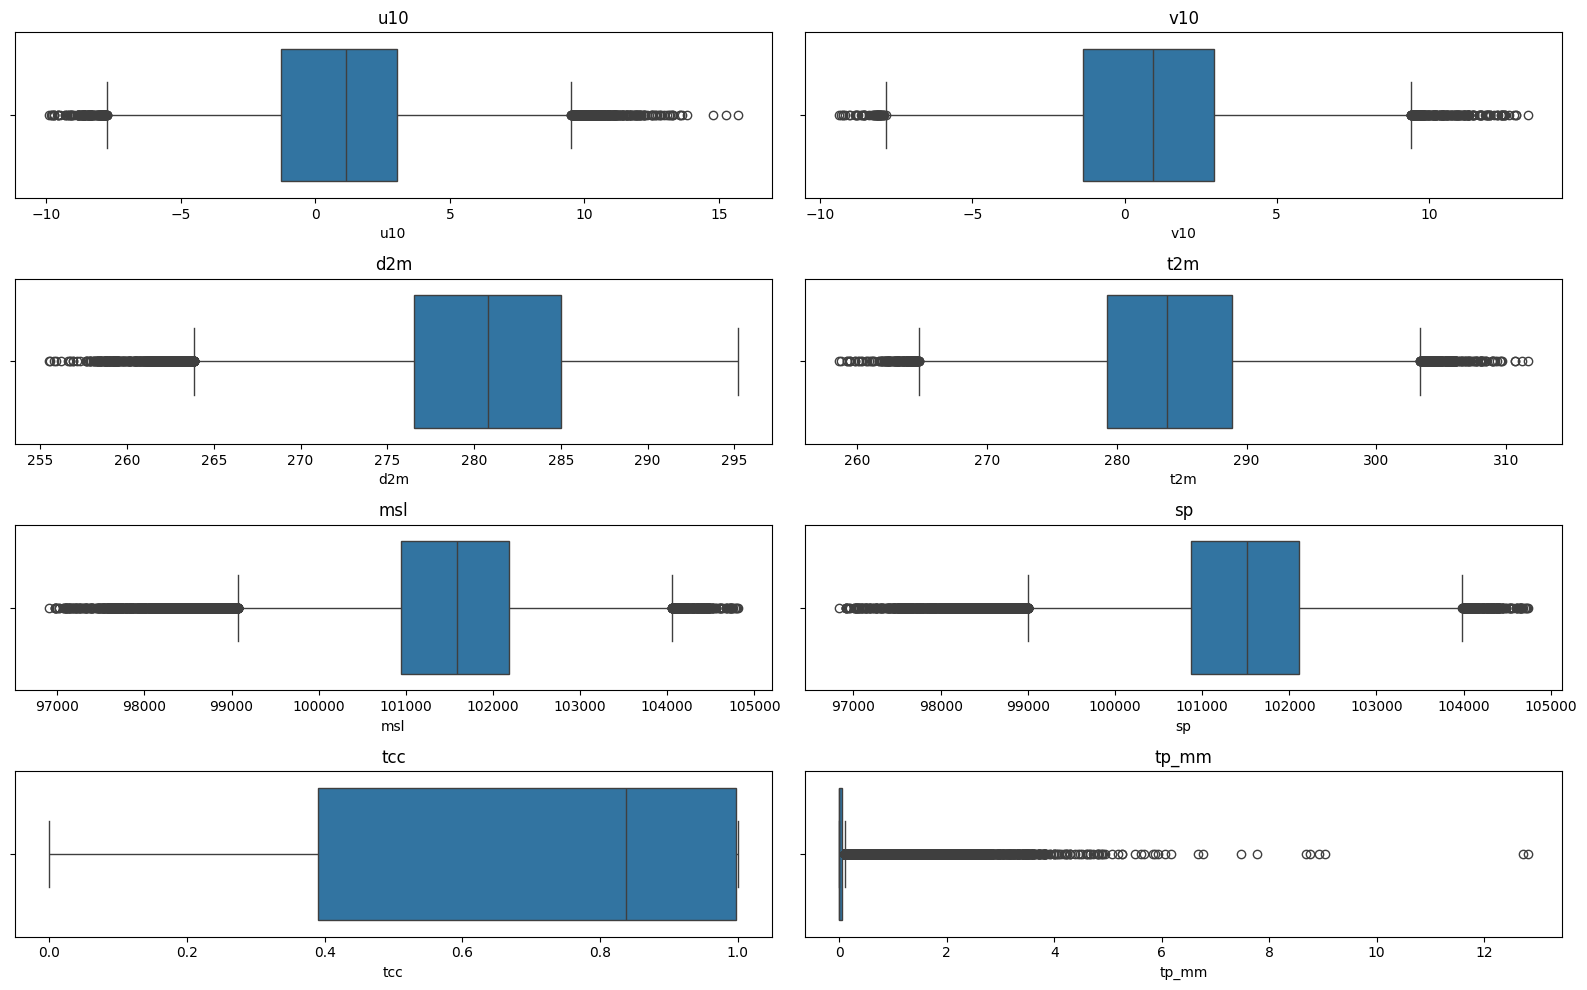

In [37]:
# boxplots
plt.figure(figsize=(16, 10))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**Scientifically important atmospheric variables below**

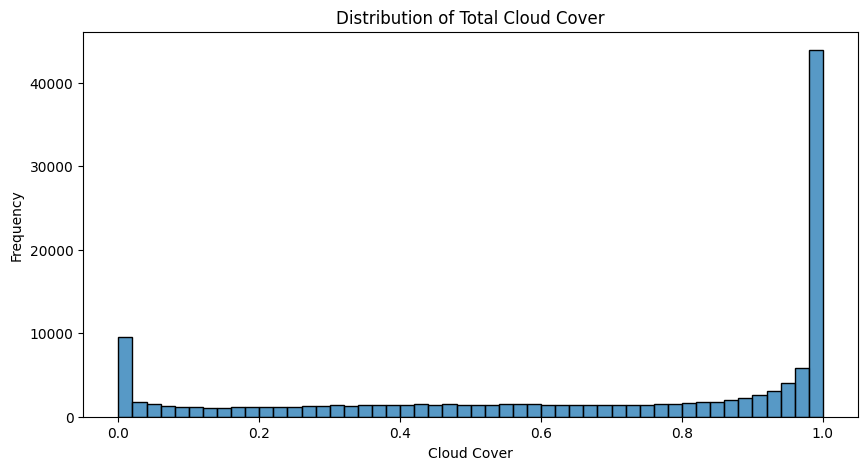

In [38]:
# distribution of cloud cover
plt.figure(figsize=(10, 5))
sns.histplot(df["tcc"], bins=50)
plt.title("Distribution of Total Cloud Cover")
plt.xlabel("Cloud Cover")
plt.ylabel("Frequency")
plt.show()

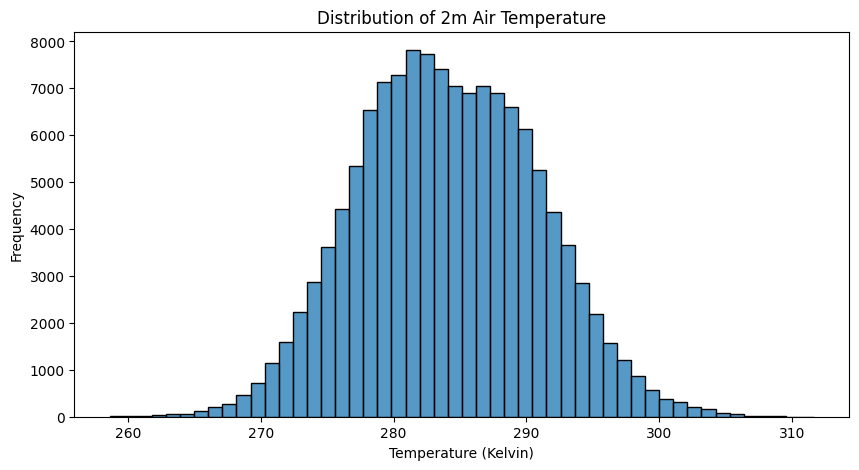

In [39]:
# Distribution in air temperature
plt.figure(figsize=(10, 5))
sns.histplot(df["t2m"], bins=50)
plt.title("Distribution of 2m Air Temperature")
plt.xlabel("Temperature (Kelvin)")
plt.ylabel("Frequency")
plt.show()

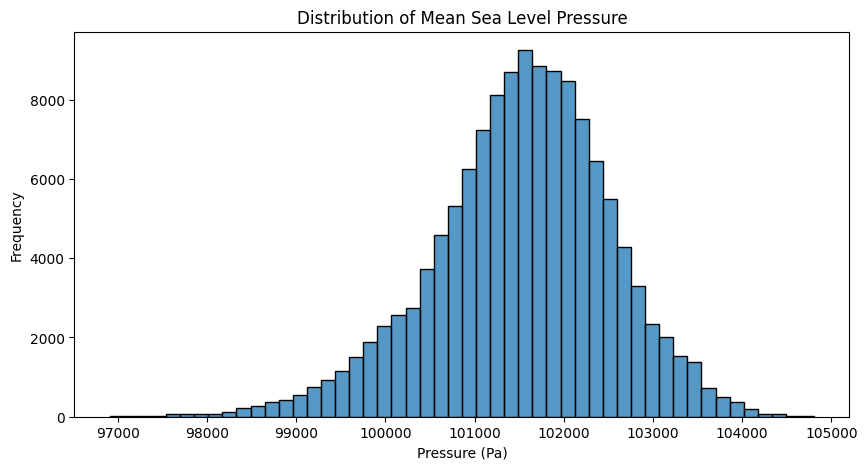

In [40]:
# Distribution of mean sea level pressure
plt.figure(figsize=(10, 5))
sns.histplot(df["msl"], bins=50)
plt.title("Distribution of Mean Sea Level Pressure")
plt.xlabel("Pressure (Pa)")
plt.ylabel("Frequency")
plt.show()

### **6.6 Bivariate Analysis**

In [41]:
# extreme precipitation indicator for EDA here first, temporary
threshold_95 = df["tp_mm"].quantile(0.95)
approx_extreme = (df["tp_mm"] >= threshold_95).astype(int)

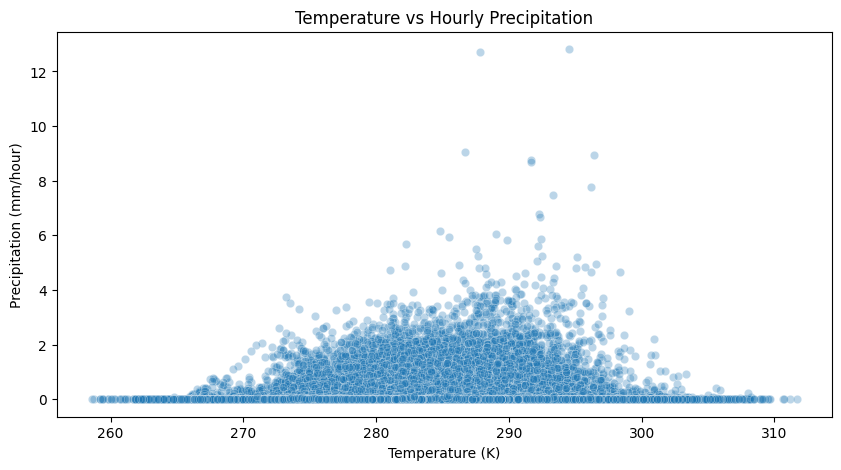

In [42]:
# Temp vs precip scatterplot
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df["t2m"], y=df["tp_mm"], alpha=0.3)
plt.title("Temperature vs Hourly Precipitation")
plt.xlabel("Temperature (K)")
plt.ylabel("Precipitation (mm/hour)")
plt.show()


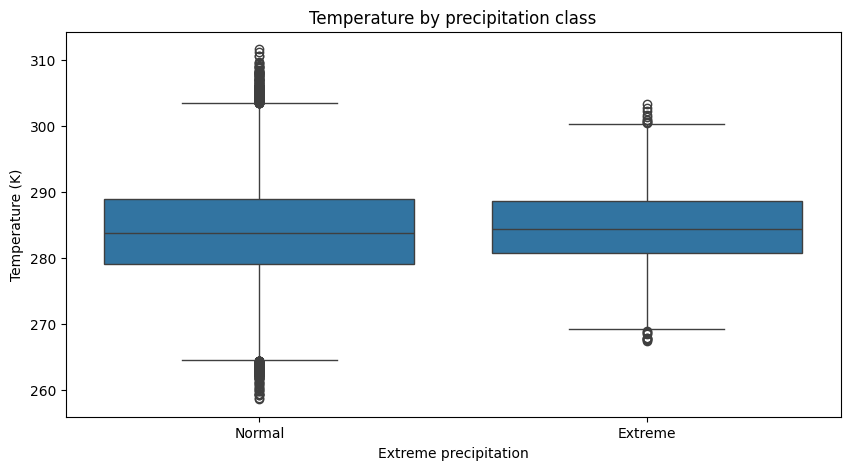

In [44]:
# the temp distribution per precipitation class

plt.figure(figsize=(10, 5))
sns.boxplot(x=approx_extreme, y=df["t2m"])
plt.title("Temperature by precipitation class")
plt.xlabel("Extreme precipitation")
plt.ylabel("Temperature (K)")
plt.xticks([0, 1], ["Normal", "Extreme"])
plt.show()

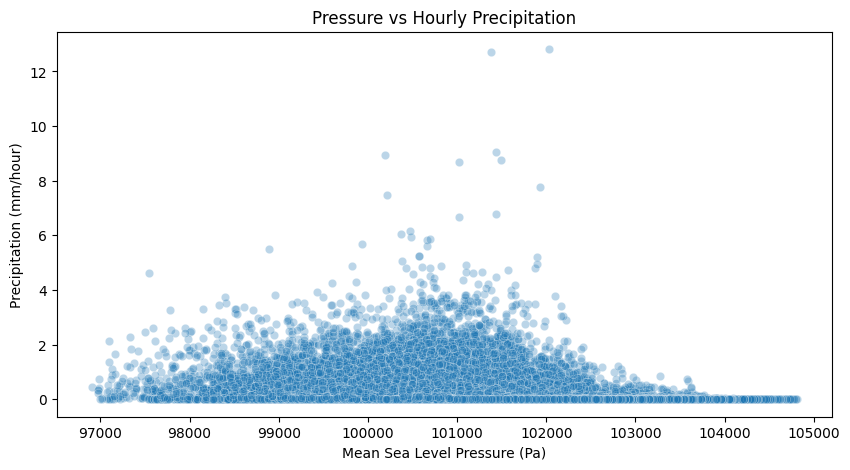

In [45]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df["msl"], y=df["tp_mm"], alpha=0.3)
plt.title("Pressure vs Hourly Precipitation")
plt.xlabel("Mean Sea Level Pressure (Pa)")
plt.ylabel("Precipitation (mm/hour)")
plt.show()

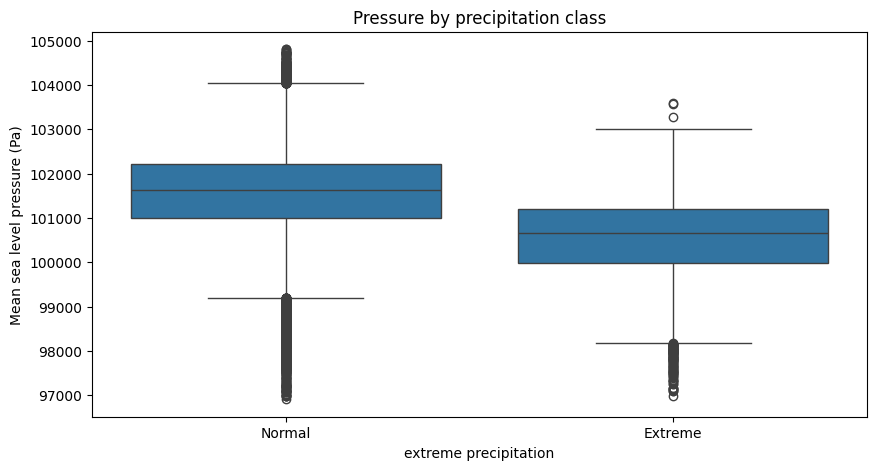

In [47]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=approx_extreme, y=df["msl"])
plt.title("Pressure by precipitation class")
plt.xlabel("extreme precipitation")
plt.ylabel("Mean sea level pressure (Pa)")
plt.xticks([0, 1], ["Normal", "Extreme"])
plt.show()

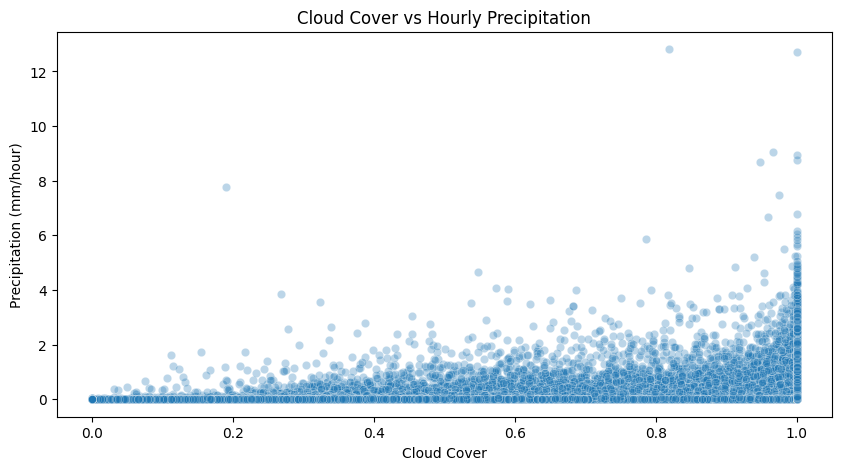

In [48]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df["tcc"], y=df["tp_mm"], alpha=0.3)
plt.title("Cloud Cover vs Hourly Precipitation")
plt.xlabel("Cloud Cover")
plt.ylabel("Precipitation (mm/hour)")
plt.show()

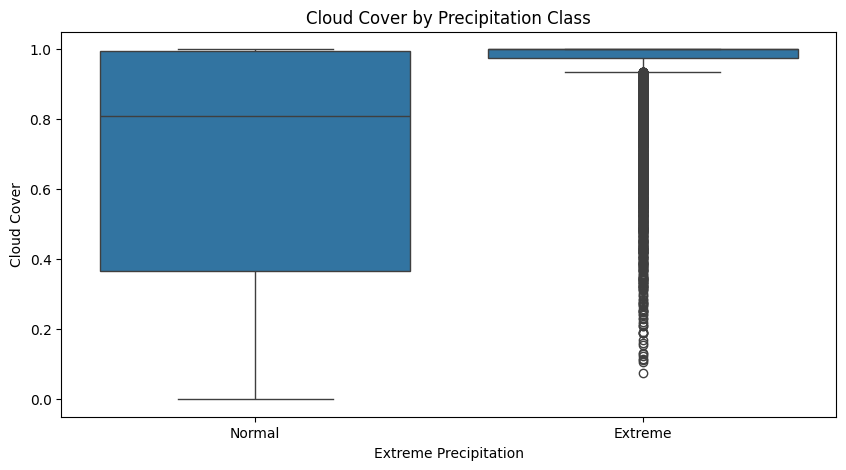

In [49]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=approx_extreme, y=df["tcc"])
plt.title("Cloud Cover by Precipitation Class")
plt.xlabel("Extreme Precipitation")
plt.ylabel("Cloud Cover")
plt.xticks([0, 1], ["Normal", "Extreme"])
plt.show()

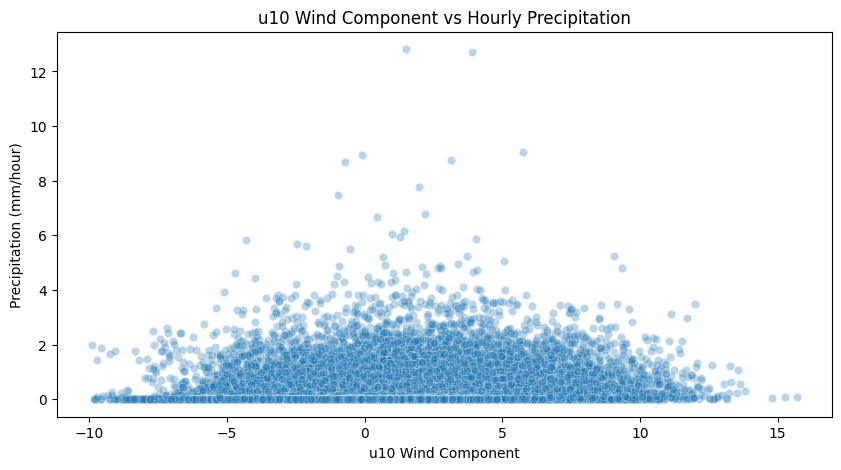

In [ ]:
# u10 wind component vs precipitation (variable definitions)
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df["u10"], y=df["tp_mm"], alpha=0.3)
plt.title("u10 Wind Component vs Hourly Precipitation")
plt.xlabel("u10 Wind Component")
plt.ylabel("Precipitation (mm/hour)")
plt.show()

In [ ]:
# v10 wind component vs precipitation (variable definitions)
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df["v10"], y=df["tp_mm"], alpha=0.3)
plt.title("v10 Wind Component vs Hourly Precipitation")
plt.xlabel("v10 Wind Component")
plt.ylabel("Precipitation (mm/hour)")
plt.show()


### **6.7 Correlation Analysis**

In [51]:
correlation_matrix = df[
    ["u10", "v10", "d2m", "t2m", "msl", "sp", "tcc", "tp_mm"]
].corr()

correlation_matrix

,u10,v10,d2m,t2m,msl,sp,tcc,tp_mm
u10,1.000000,0.263267,0.167828,0.083064,-0.169712,-0.169604,0.168526,0.118373
v10,0.263267,1.000000,0.085763,0.013504,-0.344222,-0.344184,0.203221,0.108498
d2m,0.167828,0.085763,1.000000,0.879716,-0.116312,-0.114980,0.070531,0.121853
t2m,0.083064,0.013504,0.879716,1.000000,-0.052896,-0.051495,-0.057099,0.035798
msl,-0.169712,-0.344222,-0.116312,-0.052896,1.000000,0.999999,-0.237630,-0.269510
sp,-0.169604,-0.344184,-0.114980,-0.051495,0.999999,1.000000,-0.237790,-0.269485
tcc,0.168526,0.203221,0.070531,-0.057099,-0.237630,-0.237790,1.000000,0.210097
tp_mm,0.118373,0.108498,0.121853,0.035798,-0.269510,-0.269485,0.210097,1.000000


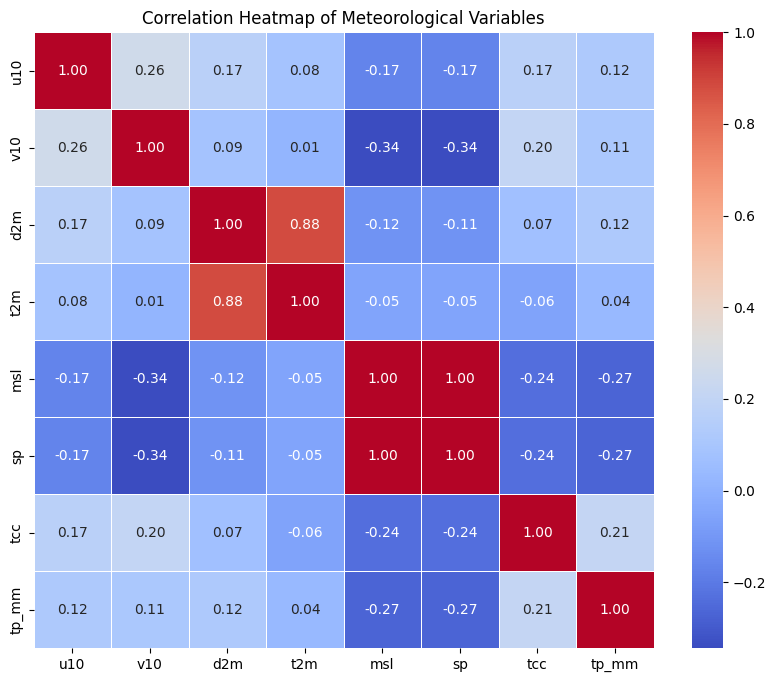

In [52]:
# to make this more clear:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Meteorological Variables")
plt.show()

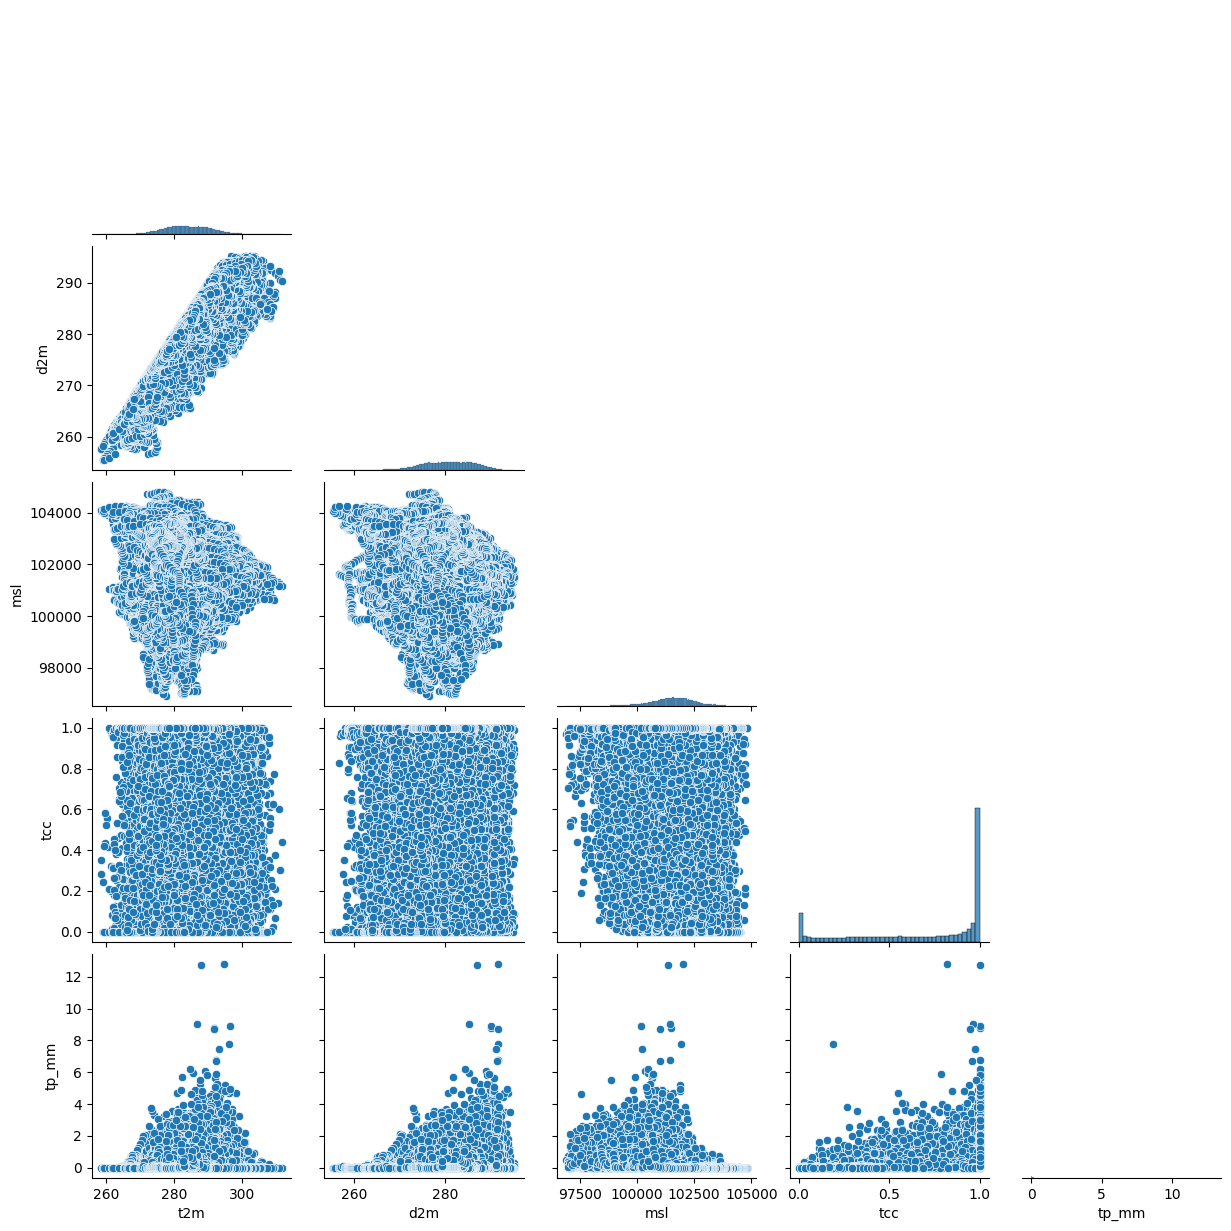

In [53]:
# pairplot with the more important features
selected_columns = ["t2m", "d2m", "msl", "tcc", "tp_mm"]
sns.pairplot(df[selected_columns], corner=True)
plt.show()

### **6.8 Outlier Analysis**

In [55]:
numerical_columns

['u10', 'v10', 'd2m', 't2m', 'msl', 'sp', 'tcc', 'tp_mm']

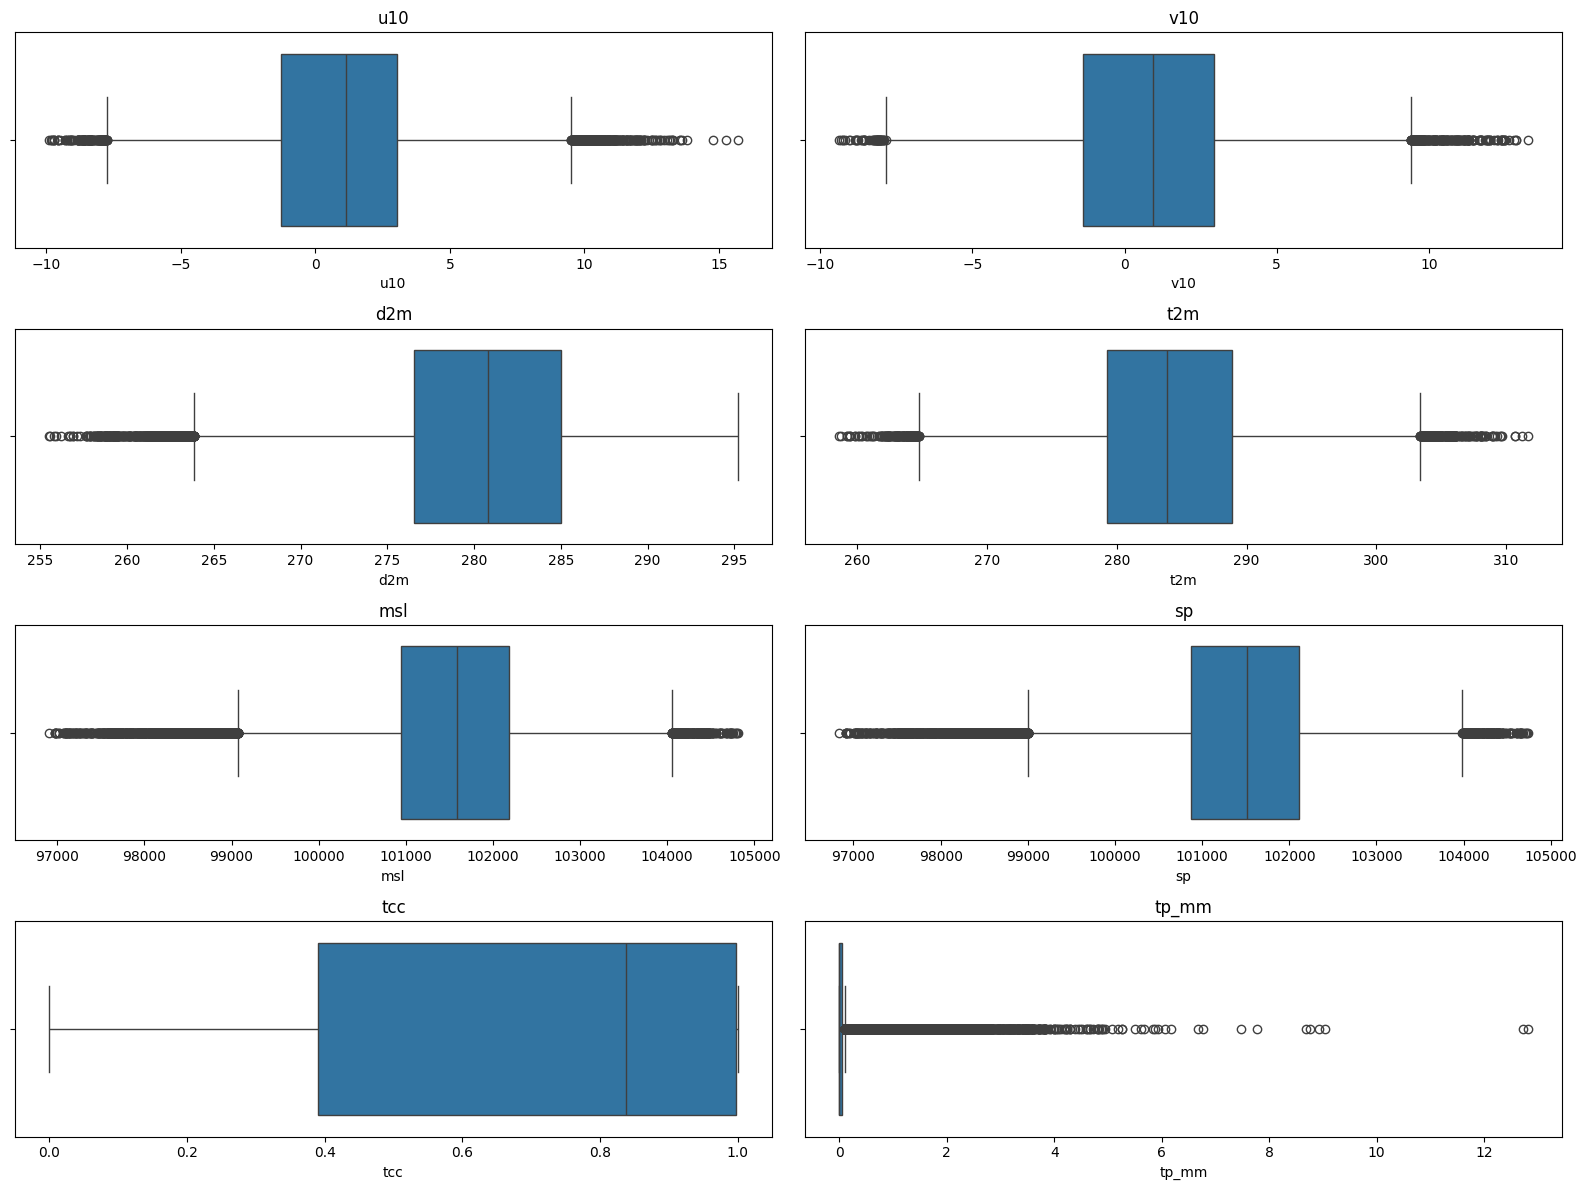

In [56]:
# outlier inspection with boxplot
plt.figure(figsize=(16, 12))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


In [58]:
# outlier calculation using IQR

outlier_summary = []

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary.append(
        {
            "Variable": col,
            "Outlier_Count": len(outliers),
            "Outlier_Percentage": (len(outliers) / len(df)) * 100,
        }
    )

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Variable,Outlier_Count,Outlier_Percentage
0,u10,508,0.386253
1,v10,277,0.210614
2,d2m,603,0.458485
3,t2m,479,0.364203
4,msl,2404,1.827859
5,sp,2400,1.824818
6,tcc,0,0.000000
7,tp_mm,22838,17.364659


In [59]:
# highest outlier percentages
outlier_summary.sort_values(by="Outlier_Percentage", ascending=False)

,Variable,Outlier_Count,Outlier_Percentage
7,tp_mm,22838,17.364659
4,msl,2404,1.827859
5,sp,2400,1.824818
2,d2m,603,0.458485
0,u10,508,0.386253
3,t2m,479,0.364203
1,v10,277,0.210614
6,tcc,0,0.000000


### **6.9 Temporal Analysis**

In [60]:
# Create time-series dataframe
df_time = df.set_index("valid_time")

In [62]:
# Monthly average precipitation
monthly_precip = df_time["tp_mm"].resample("ME").mean()

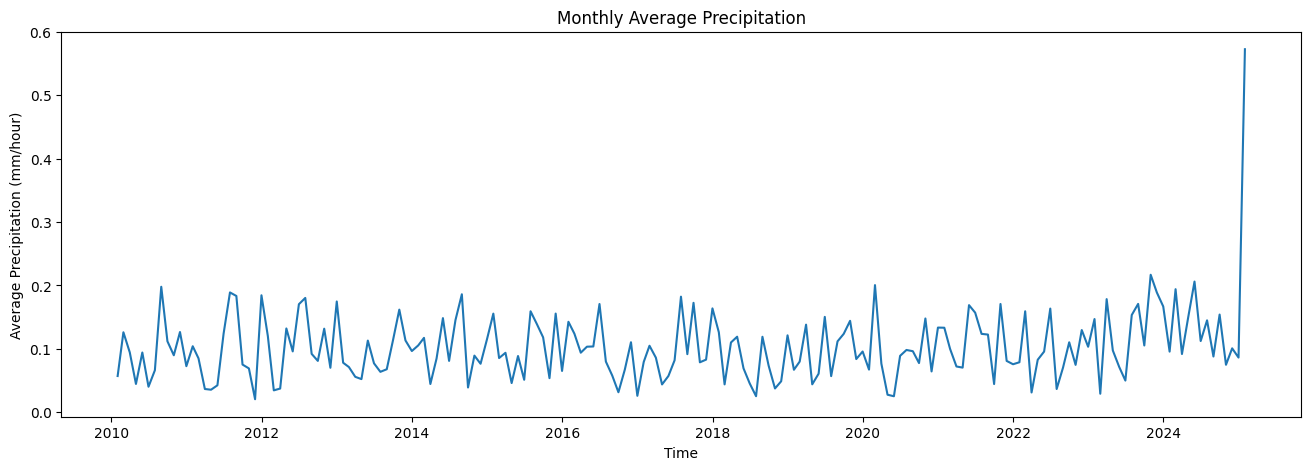

In [63]:
# monthly average precipitation
plt.figure(figsize=(16, 5))
plt.plot(monthly_precip.index, monthly_precip.values)
plt.title("Monthly Average Precipitation")
plt.xlabel("Time")
plt.ylabel("Average Precipitation (mm/hour)")
plt.show()


In [64]:
extreme_events = (df_time["tp_mm"] >= threshold_95).astype(int)

In [65]:
#monthly extreme-event counts
monthly_extremes = extreme_events.resample("ME").sum()

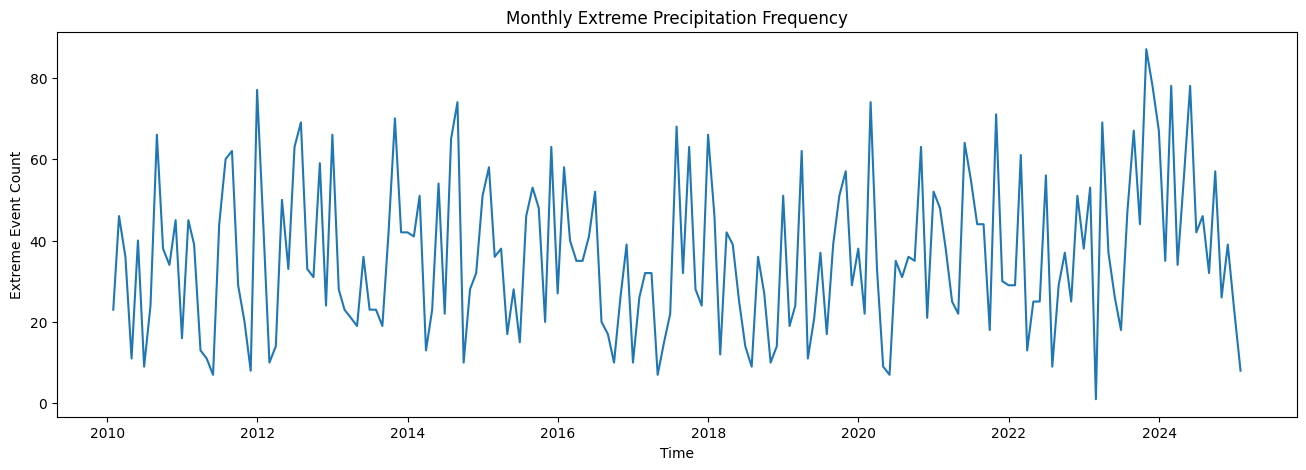

In [66]:
# monthly extreme-event counts

plt.figure(figsize=(16, 5))
plt.plot(monthly_extremes.index, monthly_extremes.values)
plt.title("Monthly Extreme Precipitation Frequency")
plt.xlabel("Time")
plt.ylabel("Extreme Event Count")
plt.show()

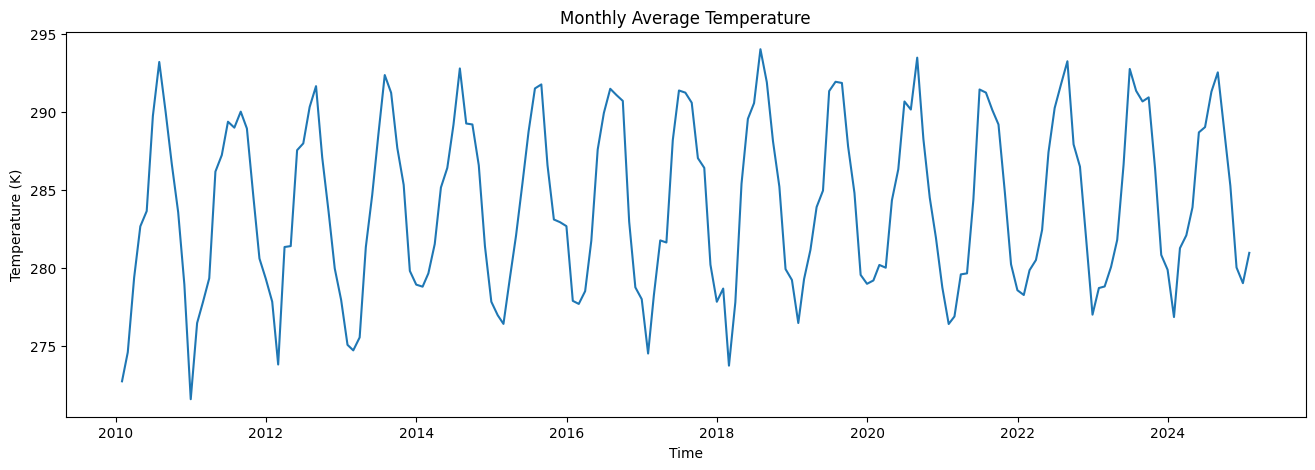

In [67]:
# Monthly average temperature

monthly_temperature = df_time["t2m"].resample("ME").mean()
plt.figure(figsize=(16, 5))
plt.plot(monthly_temperature.index, monthly_temperature.values)
plt.title("Monthly Average Temperature")
plt.xlabel("Time")
plt.ylabel("Temperature (K)")
plt.show()

**Overall**

In total there are 131,520 hourly observation for our ERA5 grid point in De Bilt (52.0 Lat 5.25 Long). In this first analysis, I did not find any missing values or duplicate rows, meaning the raw data quality is good for preprocessing and feature engineering. 

From the data one can see that hourly precipitation is strongly right-skewed. The median value for hourly precipitation is close to 0 but the maximium is about 12.81 mm. 

In total there is approximately 52,4% of hours that have any amount of precipiation. Only 2,48% of all hours exceeds 1 mm. In addition, 0.017% of all rain hours have more than 5 mm. Overall this means it is imbalanced.

Percentile based targeting is the right call as expected, rather than a fixed rainfall threshold. This is more sustainbale and easier to apply. My first suggestion is to use the 97.5th percentile which is about 1.00 mm/hour and covers 3288 cases (2.5%). 

Extreme precipitation hours show an obvious pattern. If we try to compare extreme and non extreme events, the most obvious variables and most informative predictors are pressure (difference of 10.7 hPa), cloud cover (higher total cloud cover by 0.27), atmospheric moisture (3.84C higher dew point) and wind conditions (higher 10m wind speed by 1.38m/s)

This is also confirmed in the correlation analysis: precipitation has its best linear relationship with mean sea level pressure and surface pressure (negative direction). Weaker positive relations are total cloud cover, wind speed, and as I said earlier dew point temperature. The relations are moderate so a non linear model (like XGBoost) are useful for these interactions between all these variables. 

**Seasonal**

The extreme events are seasonally structured -> the events with the most hourly precipiation occur from June through August approx, but also October seems to have elevated rates. Extreme events happen more often during the afternoon from 13:00-16:00. 
These patterns justify adding features such as month or season in my opinion. 

**Implications for preprocessing and feature engineering**

- Add converted physical units and derived predicators -> precipitation in mm, temperature and dew point in Celcius, pressure in hPa, wind speed ?, wind direction, month, season.
- The target variable is going to be a new variable extreme_precip that uses the 99th percentile threshold (approx 1.52 mm/hour) and have an additional 97.5th percentile (approx 1.00 mm/hour) as backup in case the 99th one becomes too unstable 
- Something imporant is that observations are ordered in time, mmeaning model evaluation needs to be a chronological train/test split (if possible) rather than a random one (leakage)
- Handle class imbalance 
- Unsure yet what metric to use. 
- For feature engineering: lagged and rolling variables can be very useful: for pressure, cloud cover, wind speed, dew point and previous precipitation. This allows to capture not just one single observation but also a developing weather condition.